## Housekeeping ##

<span style="font-size:18px">Import packages
    
<span style="font-size:18px">Import four datafiles: Image validation, image debrief, Ganzflicker experience, and imagery questionnaire
    
<span style="font-size:18px">Clean DFs and create and save final combined DF for analysis

In [1]:
import pandas as pd
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, pointbiserialr

In [2]:
# Path to participant questionnaire CSV files
directory_path_questionnaires = '../questionnaire_results'
directory_path_ganzflicker_experience = '../ganzflicker_experience_results'
directory_path_image_validation = '../results/image_selection.json'
directory_path_image_debrief = '../results/image_debrief.json'

In [3]:
# Load image validation JSON file
with open(directory_path_image_validation, 'r') as f:
    data = json.load(f)
    
# Load and flatten image_debrief.json 
with open(directory_path_image_debrief, 'r') as f:
    data_debrief = json.load(f)

In [4]:
# Preprocess image validation datafile

# Extract the nested trial data
all_trials = []

for participant_id, trials in data['current_participant_data'].items():
    for trial in trials:
        all_trials.append(trial)  # each trial already includes subject_id

# Convert to DataFrame
df_image_validation = pd.DataFrame(all_trials)

# Rename columns
df_image_validation = df_image_validation.rename(columns={'subject_id': 'participant_id'})
df_image_validation = df_image_validation.rename(columns={'chosen_model': 'winner_model'})

# Drop the datetime column
df_image_validation = df_image_validation.drop(columns=['datetime'])

# # Preview
# df_image_validation

In [5]:
# Preprocess image debrief datafile

# Flatten the nested structure (1 entry per participant)
records = []

for participant_id, info in data_debrief['current_participant_data'].items():
    records.append(info)

# Create DataFrame
df_debrief = pd.DataFrame(records)

# Rename columns
df_debrief = df_debrief.rename(columns={
    'subject_id': 'participant_id',
    'final_image': 'winner_image',
    'detailed_feedback': 'model_feedback'
})

# # Check result
# df_debrief

In [6]:
# Function to combine questionnaire and ganzflicker experience csv files

def process_csv_files(directory_path, output_csv):
    """Process all CSV files in the directory, load them into DataFrames, and combine into one CSV file."""
    combined_df = pd.DataFrame()  # Initialize an empty DataFrame to store combined data

    # Iterate over each file in the directory
    for file_name in os.listdir(directory_path):
        if file_name.endswith('.csv'):
            file_path = os.path.join(directory_path, file_name)
            try:
                df = pd.read_csv(file_path)
                combined_df = pd.concat([combined_df, df], ignore_index=True)
            except Exception as e:
                print(f"Error reading {file_name}: {e}")

    # Once all files are processed, write the combined dataframe to a CSV
    if not combined_df.empty:
        combined_df.to_csv(output_csv, index=False)
    else:
        print("No data to write.")

# Path to the combined CSV file
output_csv_questionnaires = 'combined_questionnaires.csv'
output_csv_ganzflicker_experience = 'combined_ganzflicker_experience.csv'

# Process the CSV files
process_csv_files(directory_path_questionnaires, output_csv_questionnaires)
process_csv_files(directory_path_ganzflicker_experience, output_csv_ganzflicker_experience)

In [7]:
# Read the CSV files into a dataframe
df_questionnaires = pd.read_csv(output_csv_questionnaires)
df_ganzflicker_experience = pd.read_csv(output_csv_ganzflicker_experience)

In [8]:
# Convert vviq responses to numbers
def update_response(value):
    if isinstance(value, str):  # only process if it's a string
        if 'No image' in value:
            return 1
        elif 'Dim' in value:
            return 2
        elif 'Moderately' in value:
            return 3
        elif 'reasonably' in value:
            return 4
        elif 'Perfectly' in value:
            return 5
        else:
            return value  # Return the original value if none of the conditions are met

# Apply the function to the 'response' column
df_questionnaires['response'] = df_questionnaires['response'].apply(update_response)

In [9]:
# Remove empty (irrelevant) columns from questionnaires dataframe
columns_to_remove = ['trial_index', 'internal_node_id', 'category', 'time_elapsed', 'item', 'questionnaire']
df_questionnaires.drop(columns_to_remove, axis=1, inplace=True)

In [10]:
# Create names for demographic questions
for i in df_questionnaires.index:
    # Rule 1: After vviq-16 comes previous_participation
    if i > 0 and pd.isna(df_questionnaires.at[i, 'item_id']) and df_questionnaires.at[i-1, 'item_id'] == 'vviq-16':
        df_questionnaires.at[i, 'item_id'] = 'previous_participation'

    # Rule 2: Gender responses
    if df_questionnaires.at[i, 'response'] in ["Woman", "Man", "Non-binary", "Prefer not to say", "Prefer to self-describe"]:
        df_questionnaires.at[i, 'item_id'] = 'gender'

    # Rule 3: Handedness
    if df_questionnaires.at[i, 'response'] in ["Right", "Left"]:
        df_questionnaires.at[i, 'item_id'] = 'handedness'

        # Rule 4: Normal vision right after handedness
        if i + 1 in df_questionnaires.index and pd.isna(df_questionnaires.at[i + 1, 'item_id']):
            df_questionnaires.at[i + 1, 'item_id'] = 'normal_vision'

            # Rule 5: English speaker right after normal vision
            if i + 2 in df_questionnaires.index and pd.isna(df_questionnaires.at[i + 2, 'item_id']):
                df_questionnaires.at[i + 2, 'item_id'] = 'english_speaker'

    # Rule 6: Education levels
    if df_questionnaires.at[i, 'response'] in ["High School", "Bachelor's Degree", "Master's Degree", "Doctoral Degree"]:
        df_questionnaires.at[i, 'item_id'] = 'education'

        # Rule 7: Diagnosis directly after education
        if i + 1 in df_questionnaires.index and pd.isna(df_questionnaires.at[i + 1, 'item_id']):
            df_questionnaires.at[i + 1, 'item_id'] = 'diagnosis'

    # Rule 8: Age > 11
    try:
        val = float(df_questionnaires.at[i, 'response'])
        if val > 11:
            df_questionnaires.at[i, 'item_id'] = 'age'

            # Rule 9: Debrief directly after age
            if i + 1 in df_questionnaires.index and pd.isna(df_questionnaires.at[i + 1, 'item_id']):
                df_questionnaires.at[i + 1, 'item_id'] = 'debrief'
    except (ValueError, TypeError):
        continue


In [11]:
# Drop general feedback rows
df_questionnaires = df_questionnaires.dropna(subset=['item_id'])

In [12]:
# Pivot the DataFrame
df_questionnaires = df_questionnaires.pivot(index='participant_id', columns='item_id', values='response')

# Reset the index to convert 'subject' from an index to a column
df_questionnaires.reset_index(inplace=True)

# Remove the index name to clean up the DataFrame presentation
df_questionnaires.columns.name = None

In [13]:
# Add z-scored vviq
# Filter columns that contain 'vviq' in their name
vviq_columns = df_questionnaires.filter(like='vviq').columns

# Sum these columns row-wise and create a new column 'vviq_sum'
df_questionnaires['vviq_sum'] = df_questionnaires[vviq_columns].sum(axis=1)
mean_vviq_sum = df_questionnaires['vviq_sum'].mean()
std_vviq_sum = df_questionnaires['vviq_sum'].std()

# Calculate z-scores for 'vviq_sum'
df_questionnaires['vviq_z'] = (df_questionnaires['vviq_sum'] - mean_vviq_sum) / std_vviq_sum

In [14]:
# Preprocess df_ganzflicker_experience

df_ganzflicker_experience = df_ganzflicker_experience.drop(
    columns=[
        col for col in df_ganzflicker_experience.columns 
        if 'auditory' in col or col == 'heard_sounds'
    ]
)

In [15]:
# Combine all four dataframes

# # Check that participant_id values match across all dataframes
# sets = {
#     "image_validation": set(df_image_validation['participant_id']),
#     "debrief": set(df_debrief['participant_id']),
#     "ganzflicker_experience": set(df_ganzflicker_experience['participant_id']),
#     "questionnaires": set(df_questionnaires['participant_id'])
# }

# # Compare all pairs and show differences
# from itertools import combinations

# for (name1, ids1), (name2, ids2) in combinations(sets.items(), 2):
#     if ids1 != ids2:
#         print(f"Mismatch between {name1} and {name2}:")
#         print(f"  In {name1} but not in {name2}: {sorted(ids1 - ids2)}")
#         print(f"  In {name2} but not in {name1}: {sorted(ids2 - ids1)}\n")

# Remove 0s from the beginning of participant_id
def normalize_ids(df):
    df['participant_id'] = df['participant_id'].astype(str).str.lstrip('0')
    return df

df_image_validation = normalize_ids(df_image_validation)
df_debrief = normalize_ids(df_debrief)
df_ganzflicker_experience = normalize_ids(df_ganzflicker_experience)
df_questionnaires = normalize_ids(df_questionnaires)

In [16]:
# Check dimensions of each df

for name, df in [
    ("df_image_validation", df_image_validation),
    ("df_debrief", df_debrief),
    ("df_ganzflicker_experience", df_ganzflicker_experience),
    ("df_questionnaires", df_questionnaires)
]:
    print(f"{name:<30} Rows: {df.shape[0]:<5}  Columns: {df.shape[1]}")

df_image_validation            Rows: 63     Columns: 12
df_debrief                     Rows: 9      Columns: 7
df_ganzflicker_experience      Rows: 9      Columns: 16
df_questionnaires              Rows: 9      Columns: 30


In [17]:
# Start with df_image_validation and merge the rest
df_merged = df_image_validation.copy()

# Merge participant-level dataframes (one-to-many join)
df_merged = df_merged.merge(df_debrief, on='participant_id', how='left')
df_merged = df_merged.merge(df_ganzflicker_experience, on='participant_id', how='left')
df_merged = df_merged.merge(df_questionnaires, on='participant_id', how='left')

# df_merged

In [18]:
# # Save preprocessed dataframe
# df_merged.to_csv('combined_all.csv')

## Demographics analysis ##

<span style="font-size:18px">Imagery score distributions
    
<span style="font-size:18px">Relationship between VVIQ and single-item imagery likert
    
<span style="font-size:18px">Relationship between VVIQ and demographic variables

<!-- Failed at least one attention checks: 170 ppts

Left with: 422 ppts -->

/var/folders/4_/n1p8tswd39b0jr38l2pdhr4r0000gn/T/ipykernel_50392/1373538408.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique['visual_likert'] = pd.to_numeric(df_unique['visual_likert'], errors='coerce')
/var/folders/4_/n1p8tswd39b0jr38l2pdhr4r0000gn/T/ipykernel_50392/1373538408.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


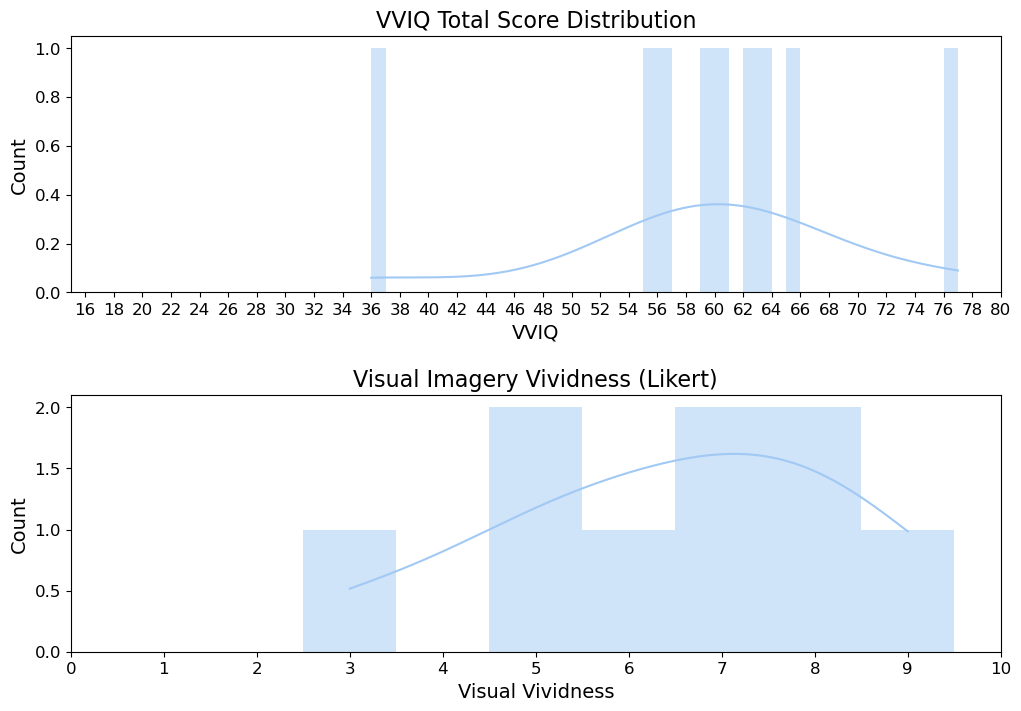

In [26]:
# Set up 2-row subplot
# Use only one row per participant to avoid repeated counts
df_unique = df_merged.drop_duplicates(subset='participant_id')
df_unique['visual_likert'] = pd.to_numeric(df_unique['visual_likert'], errors='coerce')
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=False, gridspec_kw={'hspace': 0.4})

# --- Plot 1: VVIQ ---
sns.histplot(
    df_unique['vviq_sum'],
    kde=True,
    binwidth=1,
    ax=axes[0],
    color=sns.color_palette("pastel")[0],  # light color
    edgecolor=None
)
axes[0].set_title('VVIQ Total Score Distribution', fontsize=16)
axes[0].set_xlim(15, 80)
axes[0].set_xticks(range(16, 82, 2))
axes[0].tick_params(axis='both', labelsize=12)
axes[0].set_ylabel("Count", fontsize=14)
axes[0].set_xlabel("VVIQ", fontsize=14)

# --- Plot 2: Visual Vividness ---
sns.histplot(
    df_unique['visual_likert'],
    kde=True,
    discrete=True,
    ax=axes[1],
    stat='count',
    color=sns.color_palette("pastel")[0],
    edgecolor=None
)
axes[1].set_title('Visual Imagery Vividness (Likert)', fontsize=16)
axes[1].set_xlim(0, 10)
axes[1].tick_params(axis='both', labelsize=12)
axes[1].set_xticks(range(0, 11, 1))
axes[1].set_ylabel("Count", fontsize=14)
axes[1].set_xlabel("Visual Vividness", fontsize=14)

plt.tight_layout()
plt.show()

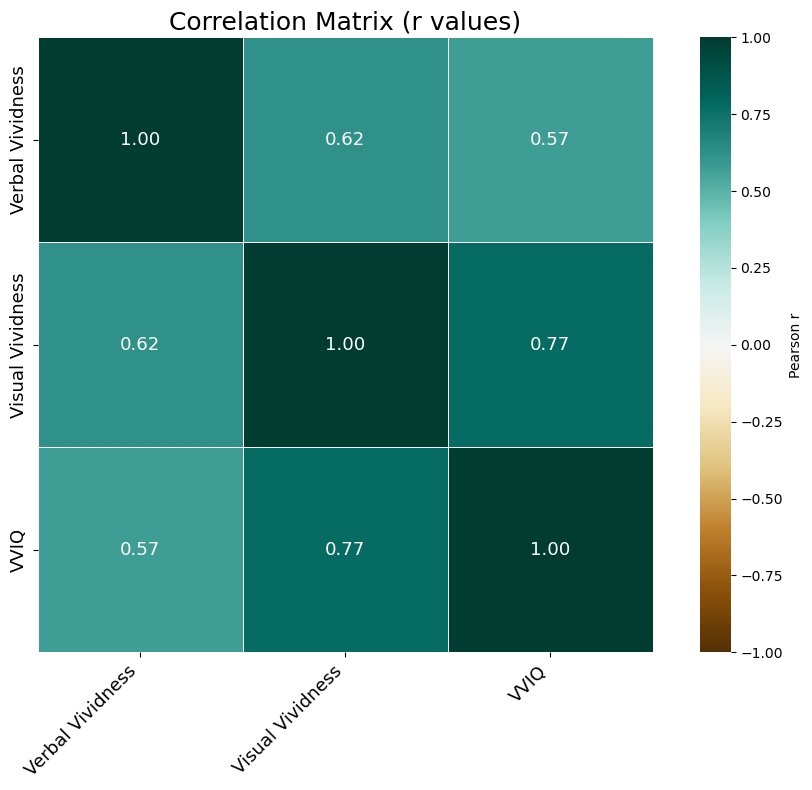

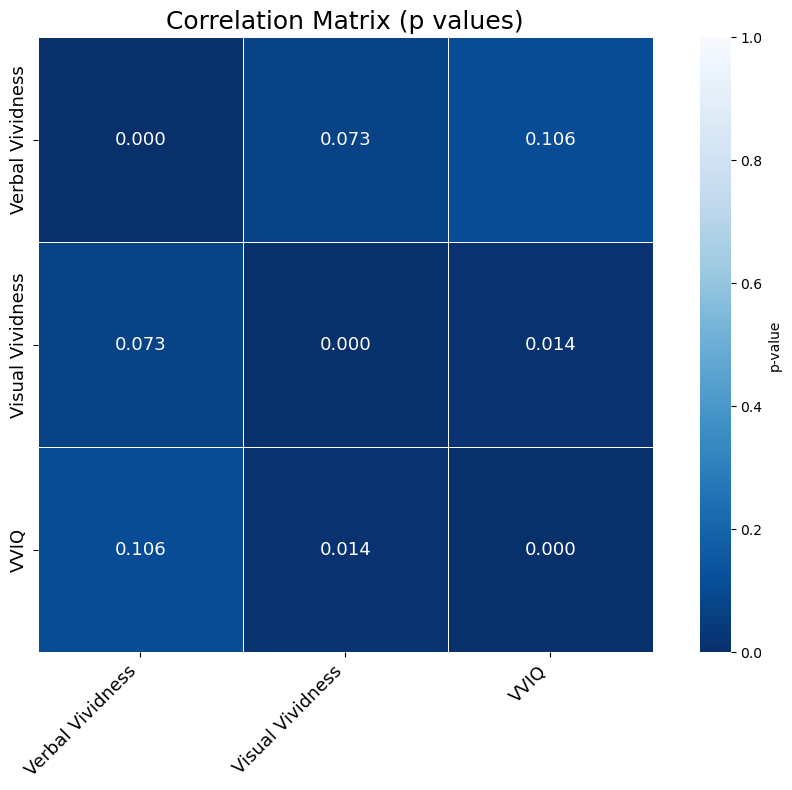

In [27]:
# Original columns
cols = ['verbal_likert', 'visual_likert', 'vviq_z']

# Rename for display
label_map = {
    'verbal_likert': 'Verbal Vividness',
    'visual_likert': 'Visual Vividness',
    'vviq_z': 'VVIQ'
}

# Convert to numeric and clean data
data = df_unique[cols].copy()
for col in cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')
data = data.dropna()
data = data.rename(columns=label_map)
pretty_cols = list(data.columns)

# Initialize matrices
r_matrix = pd.DataFrame(index=pretty_cols, columns=pretty_cols)
p_matrix = pd.DataFrame(index=pretty_cols, columns=pretty_cols)

# Calculate Pearson r and p-values
for col1 in pretty_cols:
    for col2 in pretty_cols:
        r, p = pearsonr(data[col1], data[col2])
        r_matrix.loc[col1, col2] = r
        p_matrix.loc[col1, col2] = p

# Convert to float
r_matrix = r_matrix.astype(float)
p_matrix = p_matrix.astype(float)

# # Some palettes I like
# PRGn_r, coolwarm, seismic, RdBu, PiYG, Spectral

# === Correlation heatmap (r) ===
plt.figure(figsize=(10, 8))
sns.heatmap(
    r_matrix, annot=True, fmt=".2f", cmap="BrBG", vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={"label": "Pearson r"},
    annot_kws={"fontsize": 13}
)
plt.title("Correlation Matrix (r values)", fontsize=18)
plt.xticks(fontsize=13, rotation=45, ha='right')
plt.yticks(fontsize=13)
plt.tight_layout()
plt.show()

# === p-value heatmap ===
plt.figure(figsize=(10, 8))
sns.heatmap(
    p_matrix, annot=True, fmt=".3f", cmap="Blues_r", vmin=0, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={"label": "p-value"},
    annot_kws={"fontsize": 13}
)
plt.title("Correlation Matrix (p values)", fontsize=18)
plt.xticks(fontsize=13, rotation=45, ha='right')
plt.yticks(fontsize=13)
plt.tight_layout()
plt.show()


In [28]:
# Calculate relationship between demographic variables and VVIQ

# Use pivoted df
df = df_unique.copy()
vviq = pd.to_numeric(df['vviq_z'], errors='coerce')

# Collect results
results = []

# 1. Age (continuous)
try:
    age = pd.to_numeric(df['age'], errors='coerce')
    mask = age.notna() & vviq.notna()
    r, p = pearsonr(age[mask], vviq[mask])
    results.append({'Variable': 'Age', 'Test': 'Pearson r', 'p-value': p, 'Effect size': r})
except Exception as e:
    print("Age correlation error:", e)

# 2. Normal Vision (binary)
try:
    binary = df['normal_vision'].map({'Yes': 1, 'No': 0})
    mask = binary.notna() & vviq.notna()
    r, p = pointbiserialr(binary[mask], vviq[mask])
    results.append({'Variable': 'Normal Vision', 'Test': 'Point-biserial r', 'p-value': p, 'Effect size': r})
except Exception as e:
    print("Normal vision error:", e)

# 3. Categorical variables
categorical_vars = ['gender', 'education', 'handedness', 'diagnosis']

for var in categorical_vars:
    try:
        groups = df[[var, 'vviq_z']].dropna()
        grouped_values = [g['vviq_z'].astype(float) for _, g in groups.groupby(var)]
        if len(grouped_values) > 1:
            stat, p = f_oneway(*grouped_values)
            results.append({'Variable': var.capitalize(), 'Test': 'ANOVA', 'p-value': p, 'Effect size': np.nan})
        else:
            results.append({'Variable': var.capitalize(), 'Test': 'ANOVA', 'p-value': np.nan, 'Effect size': np.nan})
    except Exception as e:
        print(f"{var} ANOVA error:", e)

# Convert to DataFrame
summary_df = pd.DataFrame(results)

# Only format if the p-value column exists
if not summary_df.empty:
    if 'p-value' in summary_df.columns:
        summary_df['p-value'] = summary_df['p-value'].round(4)
    if 'Effect size' in summary_df.columns:
        summary_df['Effect size'] = summary_df['Effect size'].round(3)

# Display
summary_df

gender ANOVA error: name 'f_oneway' is not defined
education ANOVA error: name 'f_oneway' is not defined
handedness ANOVA error: name 'f_oneway' is not defined
diagnosis ANOVA error: name 'f_oneway' is not defined


/opt/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:5405: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


,Variable,Test,p-value,Effect size
0,Age,Pearson r,0.2945,0.394
1,Normal Vision,Point-biserial r,NaN,NaN


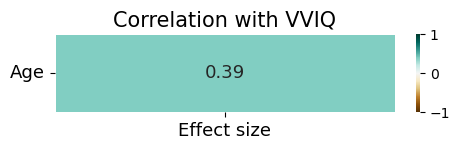

In [29]:
# Filter for rows that have a numeric effect size
heatmap_df = summary_df.dropna(subset=['Effect size']).set_index('Variable')[['Effect size']]

# Create the heatmap
plt.figure(figsize=(5, len(heatmap_df) * 0.6 + 1))  # Dynamic height
sns.heatmap(
    heatmap_df,
    annot=True,
    cmap="BrBG",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={'label': ''},
    annot_kws={"fontsize": 13}
)

plt.title("Correlation with VVIQ", fontsize=15)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13, rotation=0)
plt.ylabel("")
plt.tight_layout()
plt.show()


In [30]:
# Use the correct dataframe
df = df_unique.copy()

# Prepare summary dictionary
summary = {}

# 1. Age: Mean ± SD
df['age'] = pd.to_numeric(df['age'], errors='coerce')
age_mean = df['age'].mean()
age_sd = df['age'].std()
summary['Age (mean ± SD)'] = f"{age_mean:.2f} ± {age_sd:.2f}"

# 2. Normal vision: % Yes
if 'normal_vision' in df.columns:
    normal_vision_pct = df['normal_vision'].value_counts(normalize=True).get('Yes', 0) * 100
    summary['Normal Vision (% Yes)'] = f"{normal_vision_pct:.1f}%"

# 3. Gender distribution
if 'gender' in df.columns:
    gender_counts = df['gender'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'
    for gender, pct in gender_counts.items():
        summary[f"Gender (% {gender})"] = pct

# 4. Education distribution
if 'education' in df.columns:
    education_counts = df['education'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'
    for level, pct in education_counts.items():
        summary[f"Education (% {level})"] = pct

# 5. Handedness distribution
if 'handedness' in df.columns:
    handedness_counts = df['handedness'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'
    for hand, pct in handedness_counts.items():
        summary[f"Handedness (% {hand})"] = pct

# 6. Diagnosis: % Yes
if 'diagnosis' in df.columns:
    diagnosis_pct = df['diagnosis'].value_counts(normalize=True).get('Yes', 0) * 100
    summary['Diagnosis (% Yes)'] = f"{diagnosis_pct:.1f}%"

# 7. English speaker: % Yes
if 'english_speaker' in df.columns:
    eng_pct = df['english_speaker'].value_counts(normalize=True).get('Yes', 0) * 100
    summary['English Speaker (% Yes)'] = f"{eng_pct:.1f}%"

# Convert summary to a DataFrame
demographics_summary_df = pd.DataFrame(list(summary.items()), columns=["Variable", "Summary"])

# Display
demographics_summary_df

,Variable,Summary
0,Age (mean ± SD),24.11 ± 5.33
1,Normal Vision (% Yes),100.0%
2,Gender (% Woman),77.8%
3,Gender (% Man),22.2%
4,Education (% High School),55.6%
5,Education (% Master's Degree),33.3%
6,Education (% Bachelor's Degree),11.1%
7,Handedness (% Right),88.9%
8,Handedness (% Left),11.1%
9,Diagnosis (% Yes),0.0%


## Replicate analysis from (Königsmark et al. (2021) and Reeder (2022) ##

This summary outlines all the **statistical analyses** and **visualization methods** used in the article:

**"The Ganzflicker experience: High probability of seeing vivid and complex pseudo-hallucinations with imagery but not aphantasia"**  
*Konigsmark, Bergmann, & Reeder (2021), Cortex*

---

## 🔍 Statistical Analysis Methods

### 1. Bayesian Contingency Tables Tests
- Compared proportions (e.g., PH vs No PH across imagery groups).
- Implemented in **JASP**.
- Settings:  
  - Prior concentration = 1 (default)  
  - 1000 seeds for repeatability

### 2. Bayesian Independent-Samples Mann–Whitney U Tests
- Used for comparing ordinal/continuous variables:
  - PH vividness
  - PH complexity
  - Age
  - Total experiment time
- Settings:  
  - Cauchy prior (scale = 0.707, default)
  - 5 chains of 1000 iterations

### 3. Bayes Decision Boundary Estimation
- Determined the split between aphantasia and imagery groups.
- Used vividness rating distributions.
- Tools:
  - Python (`scipy.stats` for skewness/kurtosis)
  - Code adapted from VanderPlas (2016)

### 4. Logistic Regression
- Modeled probability of seeing PH as a function of imagery vividness.
- Tool: Python (`scipy.stats`)
- Visualization: Overlaid logistic line with 95% CI on bar plots

### 5. Gaussian Mixture Model – Expectation Maximization (GMM-EM)
- Explored differences in:
  - PH Vividness
  - PH Complexity
  - PH Emergence time
  - PH Duration
  - PH Frequency
- Tool: Python (`scikit-learn`)
- Settings:
  - 42 random states
  - Full covariance
  - Visualized via scatterplots with contour overlays

---

## 📊 Plotting Approaches

### 1. Stacked Bar Plots
- Visualized PH experience counts per imagery vividness score.
- Overlaid with logistic regression + jittered data points

### 2. Density Plots with Normal Curve
- Showed imagery vividness distributions (aphants vs imagers).
- Overlaid with normal distribution and Bayes decision boundary

### 3. Scatterplots + GMM-EM
- For each PH feature (e.g., vividness, complexity)
- Color-coded by group (green = aphants, gray = imagers)
- GMM-EM contours: likelihood and uncertainty shading

### 4. Bayesian Evidence Tables
- Summarized Bayes Factors (BF10) for all key comparisons
- Reported evidence strength for PH differences, demographic variables, etc.

### 5. Descriptive Tables
- Tables 1–4 presented:
  - PH feature codings
  - Participant demographics
  - Environmental factors
  - Group-based breakdowns

---



## Model-generated image validation ##


In [31]:
# Import merged and cleaned data
df_merged = pd.read_csv('combined_all.csv')
df_merged = df_merged.drop(columns=['Unnamed: 0'])
# Set option to display all columns
pd.set_option('display.max_columns', None)

In [32]:
# --- Precompute percentages for 'choice' ---
choice_counts = df_merged['choice'].value_counts(normalize=True).reset_index()
choice_counts.columns = ['choice', 'percent']

# --- Precompute percentages for 'winner_model' ---
winner_df = df_merged[df_merged['trial_type'] == 'final']
winner_counts = winner_df['winner_model'].value_counts(normalize=True).reset_index()
winner_counts.columns = ['winner_model', 'percent']

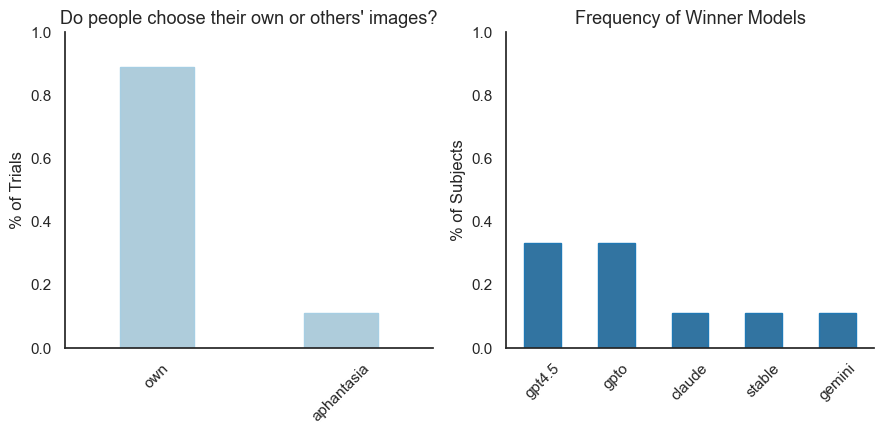

In [33]:
# Set style, no background
sns.set(style="white")

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5), sharey=False)

# --- Plot 1: Percentage of Choices ---
palette1 = sns.color_palette('Paired')
bar_color1 = palette1[0]

sns.barplot(
    data=choice_counts,
    x='choice',
    y='percent',
    color=bar_color1,
    edgecolor=bar_color1,
    width=0.4,
    ax=axes[0]
)

axes[0].set_title('Do people choose their own or others\' images?', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('% of Trials', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, 1.0)
sns.despine(ax=axes[0])

# --- Plot 2: Percentage of Winner Models ---
bar_color2 = palette1[1]

sns.barplot(
    data=winner_counts,
    x='winner_model',
    y='percent',
    width=0.5,
    color=bar_color2,
    edgecolor=bar_color2,
    ax=axes[1]
)

axes[1].set_title('Frequency of Winner Models', fontsize=13)
axes[1].set_xlabel('', fontsize=1)
axes[1].set_ylabel('% of Subjects')  # No need for repeated label
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0, 1.0)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

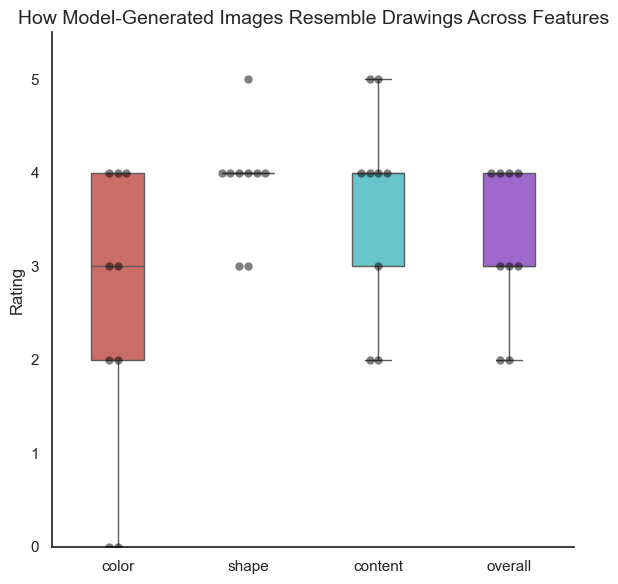

In [34]:
# Reshape to long format
melted_df = winner_df.melt(
    value_vars=['color', 'shape', 'content', 'overall'],
    var_name='dimension',
    value_name='rating'
)

# Clean style
sns.set(style="white")

plt.figure(figsize=(6, 6))

# Boxplot to show median, IQR, whiskers
sns.boxplot(
    data=melted_df,
    x='dimension',
    y='rating',
    hue='dimension',
    palette='hls',
    width=0.4,
    fliersize=0,
    legend=False  # suppress redundant legend
)

# Overlay raw data points
# sns.stripplot(data=melted_df, x='dimension', y='rating', color='black', alpha=0.5, jitter=0.2)

# Optional: Swarmplot instead (slower but avoids overlapping dots)
sns.swarmplot(data=melted_df, x='dimension', y='rating', color='black', alpha=0.5, size = 6)

# sns.pointplot(data=melted_df, x='dimension', y='rating', errorbar=('ci', 95), join=False)

plt.title('How Model-Generated Images Resemble Drawings Across Features', fontsize=14)
plt.ylabel('Rating', fontsize=12)
plt.xlabel('', fontsize=1)
plt.ylim(0, 5.5)
sns.despine()
plt.tight_layout()
plt.show()